# Heart Disease Prediction

## Import Libraries

## Load Processed Dataset

## Split Features and Target

## Train-Test Split

## Feature Scaling

## Train Models

## Model Evaluation

## Model Comparison

## Save Best Model

## Observations

In [3]:
# Import Libraries
import pandas as pd
import joblib 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import(accuracy_score, precision_score,
                            recall_score,f1_score,
                            confusion_matrix, 
                            classification_report)

In [4]:
# Load DataSet
df = pd.read_csv("../data/processed/processed_heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
# Features & Target
X = df.drop("target", axis=1)
y = df["target"]

In [6]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 43, stratify = y)

In [7]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Train Models

In [8]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# KNN
knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
# Predictions
dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

knn_pred = knn_model.predict(X_test)

In [12]:
# Evaluatioin Function
def evaluate_model(name, y_true, y_pred):

    print("="* 50)

    print(name)

    print("="* 50)

    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")

    print(f"Precision : {precision_score(y_true, y_pred):.4f}")

    print(f"Recall : {recall_score(y_true, y_pred):.4f}")

    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")

    print()

    print("Confusion Matrix")

    print(confusion_matrix(y_true, y_pred))

    print()

    print(classification_report(y_true, y_pred))

In [13]:
# Evaluate Model
evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Random forest", y_test, rf_pred)

evaluate_model("KNN", y_test, knn_pred)



Decision Tree
Accuracy : 0.6393
Precision : 0.6571
Recall : 0.6970
F1 Score : 0.6765

Confusion Matrix
[[16 12]
 [10 23]]

              precision    recall  f1-score   support

           0       0.62      0.57      0.59        28
           1       0.66      0.70      0.68        33

    accuracy                           0.64        61
   macro avg       0.64      0.63      0.63        61
weighted avg       0.64      0.64      0.64        61

Random forest
Accuracy : 0.7869
Precision : 0.7941
Recall : 0.8182
F1 Score : 0.8060

Confusion Matrix
[[21  7]
 [ 6 27]]

              precision    recall  f1-score   support

           0       0.78      0.75      0.76        28
           1       0.79      0.82      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61

KNN
Accuracy : 0.6885
Precision : 0.6944
Recall : 0.7576
F1 Score : 0.7246

Confusion Matrix
[[17 11

In [14]:
# Comparison Table
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "Precision": [
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, knn_pred)
    ],
    "Recall": [
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, knn_pred)
    ],
    "F1 Score": [
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, knn_pred)
    ]
})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.786885,0.794118,0.818182,0.805970
2,KNN,0.688525,0.694444,0.757576,0.724638
0,Decision Tree,0.639344,0.657143,0.696970,0.676471


In [ ]:
# Store all trained models
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "KNN": knn_model
}

In [20]:
# Find the best model name based on accuracy
best_model_name = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

In [21]:
# Retrieve the trained model object
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")

Best Model: Random Forest


In [24]:
# Save the best model
joblib.dump(
    best_model,
    "../models/heart_disease_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


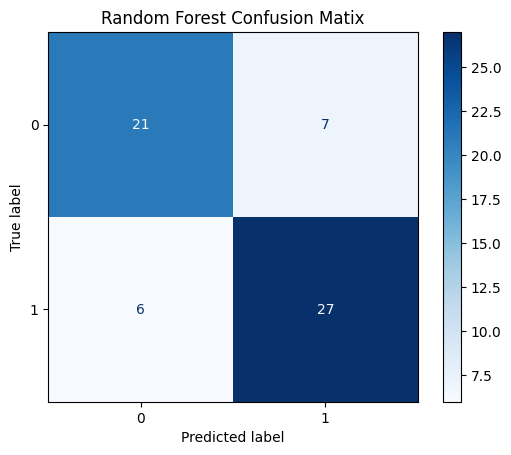

In [25]:
# Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap="Blues")

plt.title("Random Forest Confusion Matix")
plt.show()

In [26]:
# Feature Importance
feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
7,thalach,0.132560
11,ca,0.129880
2,cp,0.129686
9,oldpeak,0.112086
0,age,0.087753
12,thal,0.071838
8,exang,0.071569
4,chol,0.070971
3,trestbps,0.070633
10,slope,0.055726


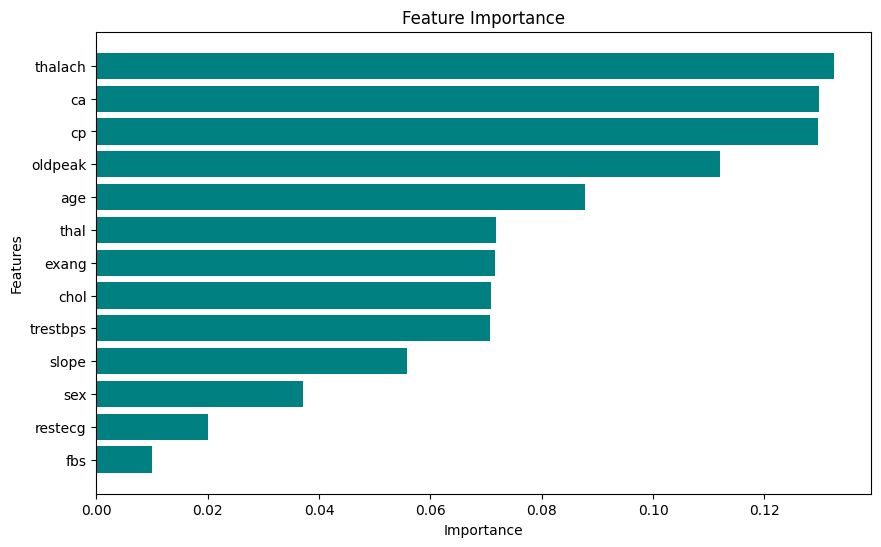

In [27]:
# Visualize Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="teal"
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

# Observations

- The processed dataset was successfully used for model training.
- Three classification algorithms were trained and evaluated:
  - Decision Tree
  - Random Forest
  - K-Nearest Neighbors (KNN)
- Random Forest achieved the highest accuracy and overall performance.
- KNN required feature scaling because it is a distance-based algorithm.
- The best-performing model was saved for deployment.
- The StandardScaler was also saved to ensure consistent preprocessing during prediction.
- Feature importance analysis showed which attributes contributed most to heart disease prediction.